<a target="_blank" href="https://colab.research.google.com/github/intensivedatacomp/WignerCamp2026/blob/main/AnomalyDetectionSignalProcessing/optuna_presentation.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Bayesian Hyperparameter Optimization with Optuna

## What is Optuna?

**Optuna** is a Python library for automatic hyperparameter optimization.

Instead of manually trying parameter values, Optuna:

- Runs a **study**: a collection of parameter evaluations.
- Each **trial** evaluates the objective function at one parameter configuration.
- The **Bayesian approach** builds a surrogate model from past trials and uses it to suggest the most promising next configuration.

## Why is this useful?

Searching for the best parameters is expensive:

- Grid search requires exponentially many evaluations.
- Random search wastes evaluations on poor regions.
- Bayesian optimization **learns** from past trials and focuses on promising regions.

## Imports

In [1]:
try:
    from google.colab import drive
    IN_COLAB = True
    drive.mount('/content/drive/')
    %cd /content/drive/My\ Drive/Colab\ Notebooks/WignerCamp2026
    !pip install optuna --quiet
except:
    IN_COLAB = False
    %load_ext autoreload
    %autoreload 2
print(f'Running on {"Google colab" if IN_COLAB else "Local computer"}')

Running on Local computer


In [2]:
import math
import optuna
import numpy as np
import matplotlib.pyplot as plt

optuna.logging.set_verbosity(optuna.logging.WARNING)

## The Core Workflow

Every Optuna optimization follows three steps:

1. **Define** an objective function that receives a `trial` and returns a scalar.
2. **Create** a study with a direction (`'minimize'` or `'maximize'`).
3. **Optimize**: let Optuna run many trials and find the best parameters.

```python
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100)

print(study.best_params)  # best parameter combination found
print(study.best_value)   # best objective value found
```

## Defining an Objective Function

The objective function receives a `trial` object and uses it to **suggest** parameter values.
The function returns a scalar which Optuna tries to minimize (or maximize).

**Example**: minimize $f(x) = (x - \pi)^2$ for $x \in [0, 10]$.

The true minimum is $x = \pi \approx 3.14159$, where $f = 0$.

In [3]:
def objective(trial):
    x = trial.suggest_float('x', 0.0, 10.0)
    return (x - math.pi) ** 2

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

print(f"Best x:     {study.best_params['x']:.6f}")
print(f"True pi:    {math.pi:.6f}")
print(f"Best value: {study.best_value:.2e}")

Best x:     3.131832
True pi:    3.141593
Best value: 9.53e-05


## Suggesting Parameter Types

The `trial` object provides four suggestion methods, one for each parameter type:

| Method | Parameter type | Example |
|---|---|---|
| `trial.suggest_float('name', low, high)` | continuous real | learning rate |
| `trial.suggest_int('name', low, high)` | integer | number of iterations |
| `trial.suggest_categorical('name', ['a', 'b'])` | unordered categories | function name |
| `trial.suggest_categorical('name', [0.1, 1.0, 10.0])` | values from a list | step size |

### Floats: `suggest_float`

Use `suggest_float` for any **continuous** parameter.

```python
x = trial.suggest_float('x', low, high)
x = trial.suggest_float('x', low, high, log=True)
```

**Example**: minimize
\begin{equation}
    f(x, y) = (x - 1)^2 + (y + 2)^2,
\end{equation}
with $x, y \in [-5, 5]$. The true minimum is $(x^*, y^*) = (1, -2)$, where $f = 0$.

In [4]:
def objective_2d(trial):
    x = trial.suggest_float('x', -5.0, 5.0)
    y = trial.suggest_float('y', -5.0, 5.0)
    return (x - 1.0)**2 + (y + 2.0)**2
study_2d = optuna.create_study(direction='minimize')
study_2d.optimize(objective_2d, n_trials=100)
print(f"Best x: {study_2d.best_params['x']:.4f}  (true: 1.0)")
print(f"Best y: {study_2d.best_params['y']:.4f}  (true: -2.0)")
print(f"Best value: {study_2d.best_value:.2e}")

Best x: 0.8180  (true: 1.0)
Best y: -1.8227  (true: -2.0)
Best value: 6.46e-02


**Exercise 1**: Run the cell above. How close to the true minimum does Optuna get with 100 trials? Change `n_trials` to 20 and 500 and observe the difference.

**Solution**: With 100 trials the best value is typically below $10^{-3}$. With 20 trials the result is less accurate; with 500 trials it is very close to 0.

### Log-scale Floats

When a parameter spans several orders of magnitude the `log=True` option is essential.
It ensures that each order of magnitude receives equal probability by sampling uniformly in log-space:
\begin{equation}
    \log \alpha \sim \text{Uniform}(\log a,\; \log b).
\end{equation}

**Example**: minimize $f(\alpha) = (\log_{10} \alpha + 2)^2$ for $\alpha \in [10^{-4}, 10^{0}]$.

The true minimum is $\alpha^* = 10^{-2} = 0.01$, which lies at the geometric center of the range.
Without `log=True`, most samples cluster near 1 and the true minimum is rarely visited.

In [5]:
def objective_log(trial):
    alpha = trial.suggest_float('alpha', 1e-4, 1.0, log=True)
    return (np.log10(alpha) + 2.0) ** 2  # minimum at alpha = 10^(-2) = 0.01

study_log = optuna.create_study(direction='minimize')
study_log.optimize(objective_log, n_trials=50)

print(f"Best alpha: {study_log.best_params['alpha']:.6f}  (true: 0.010000)")
print(f"Best value: {study_log.best_value:.2e}")

Best alpha: 0.010006  (true: 0.010000)
Best value: 6.54e-08


### Integers: `suggest_int`

Use `suggest_int` for **discrete** parameters such as counts or indices.

```python
n = trial.suggest_int('n', low, high)  # integer in {low, low+1, ..., high}
```

**Example**: minimize
\begin{equation}
    f(n) = |n^2 - 50|
\end{equation}
for $n \in \{1, 2, \ldots, 20\}$. The true minimum is $n^* = 7$, since $7^2 = 49$ is the closest perfect square to 50.

In [6]:
def objective_int(trial):
    n = trial.suggest_int('n', 1, 20)
    return abs(n**2 - 50)

study_int = optuna.create_study(direction='minimize')
study_int.optimize(objective_int, n_trials=40)

print(f"Best n:     {study_int.best_params['n']}  (true: 7)")
print(f"Best value: {study_int.best_value}  (true: |49 - 50| = 1)")

Best n:     7  (true: 7)
Best value: 1.0  (true: |49 - 50| = 1)


**Exercise 2**: Modify the objective to minimize $f(n) = |n^3 - 1000|$ for $n \in \{1, \ldots, 30\}$. What is the true minimum? Run Optuna with 30 trials and check whether it finds it.

**Solution**: $10^3 = 1000$, so $n^* = 10$ and $f(10) = 0$. Optuna finds this easily since the search space is small.

### Categorical Values: `suggest_categorical`

Use `suggest_categorical` for **unordered discrete choices** such as function names or algorithm types.

```python
choice = trial.suggest_categorical('name', ['option_a', 'option_b', 'option_c'])
```

**Example**: minimize $f(x, \text{func})$ where `func` selects the penalty shape:

| `func` | $f(x, \text{func})$ | minimum value |
|---|---|---|
| `'square'` | $(x - 2)^2 + 5$ | 5 |
| `'absolute'` | $\lvert x - 2 \rvert + 2$ | 2 |
| `'smooth'` | $\sqrt{(x-2)^2 + 0.1} - 0.1$ | $\approx 0.216$ |

Optuna should discover that `'smooth'` with $x \approx 2$ gives the smallest value.

In [7]:
def objective_cat(trial):
    func_name = trial.suggest_categorical('func',
                ['square', 'absolute', 'smooth'])
    x = trial.suggest_float('x', -10.0, 10.0)

    if func_name == 'square':
        return (x - 2.0)**2 + 5.0
    elif func_name == 'absolute':
        return abs(x - 2.0) + 2.0
    else:  # smooth
        return np.sqrt((x - 2.0)**2 + 0.1) - 0.1

study_cat = optuna.create_study(direction='minimize')
study_cat.optimize(objective_cat, n_trials=80)

print(f"Best func:  {study_cat.best_params['func']!r} (true: 'smooth')")
print(f"Best x:     {study_cat.best_params['x']:.4f}   (true: 2.0)")
print(f"Best value: {study_cat.best_value:.4f}   (true: sqrt(0.1) - 0.1 ~ 0.2162)")

Best func:  'smooth' (true: 'smooth')
Best x:     1.9856   (true: 2.0)
Best value: 0.2166   (true: sqrt(0.1) - 0.1 ~ 0.2162)


### Elements from a List: `suggest_categorical` with a List

`suggest_categorical` works with **any Python list** of values, not only strings.
This is the standard way to choose the best value from a predefined set.

```python
step = trial.suggest_categorical('step_size', [0.001, 0.01, 0.1, 1.0, 10.0])
```

**Example**: find the best step size $\eta$ for gradient descent on $f(x) = x^2$, starting from $x_0 = 10$, after 100 steps.

The update rule is:
\begin{equation}
    x_{t+1} = x_t - \eta \cdot f'(x_t) = x_t \cdot (1 - 2\eta).
\end{equation}

After 100 steps:
\begin{equation}
    x_{100} = 10 \cdot (1 - 2\eta)^{100}.
\end{equation}

A step too small converges slowly; a step $\eta \geq 1$ causes divergence.

In [8]:
STEP_SIZES = [0.0001, 0.001, 0.01, 0.1, 1.0]

def objective_list(trial):
    eta = trial.suggest_categorical('step_size', STEP_SIZES)
    x = 10.0
    for _ in range(100):
        x = x - eta * 2.0 * x  # gradient of x^2 is 2x
    return x**2

study_list = optuna.create_study(direction='minimize')
study_list.optimize(objective_list, n_trials=30)

In [9]:
print(f"Best step size: {study_list.best_params['step_size']}")
print(f"Final loss:     {study_list.best_value:.2e}")

print("\nAll step sizes and their final losses:")
for eta in STEP_SIZES:
    x = 10.0
    for _ in range(100):
        x = x - eta * 2.0 * x
    print(f"  eta={eta:.4f} -> loss={x**2:.2e}")

Best step size: 0.1
Final loss:     4.15e-18

All step sizes and their final losses:
  eta=0.0001 -> loss=9.61e+01
  eta=0.0010 -> loss=6.70e+01
  eta=0.0100 -> loss=1.76e+00
  eta=0.1000 -> loss=4.15e-18
  eta=1.0000 -> loss=1.00e+02


### Selecting a Subset from a List: Binary Mask

Sometimes the search space is not a single parameter but a **subset of a fixed list**.
The question is: which elements should be included, and how many?

The recommended Optuna pattern is a **binary mask**: create one `suggest_categorical` per element,
each choosing `True` (include) or `False` (exclude).

```python
mask = [trial.suggest_categorical(f'include_{i}', [True, False])
        for i in range(len(lst))]
```

- Each element gets its own named parameter (`include_0`, `include_1`, ...).
- The search space has $2^n$ possible subsets, where $n$ is the length of the list.
- Optuna explores this space and learns which elements are worth including.

**Example**: from the list $[-3, 1, 2, 5, 10]$, find the sublist whose sum is closest to $0$.

The objective is:
\begin{equation}
    f(\text{mask}) = \left|\sum_{i:\, \text{mask}_i = \text{True}} x_i\right|.
\end{equation}

The true answer is $\{-3, 1, 2\}$, since $-3 + 1 + 2 = 0$.

In [10]:
LST = [-3, 1, 2, 5, 10]

def objective_subset(trial):
    # One boolean decision per element
    mask = [trial.suggest_categorical(f'include_{i}', [True, False])
            for i in range(len(LST))]
    selected = [v for v, keep in zip(LST, mask) if keep]
    if not selected:
        return float('inf')  # empty subset is not useful here
    return abs(sum(selected))

study_subset = optuna.create_study(direction='minimize')
study_subset.optimize(objective_subset, n_trials=200)

mask = [study_subset.best_params[f'include_{i}'] for i in range(len(LST))]
result = [v for v, keep in zip(LST, mask) if keep]
print(f"Best subset: {result}")
print(f"Sum:         {sum(result)}")
print(f"Best value:  {study_subset.best_value}")

Best subset: [1]
Sum:         1
Best value:  1.0


**Exercise 3**: Change the target sum to $3$ (i.e. minimize $|\text{sum}(\text{sublist}) - 3|$)
and the list to $[-4, 1, 2, 3, 7]$.
What sublist do you expect Optuna to find?
Run the optimization with 200 trials and check the result.

**Solution**: The subsets that sum to $3$ are $\{3\}$ and $\{-4, 7\}$ and $\{1, 2\}$.
All three achieve the objective value $0$.
Optuna will find one of them (which one may vary between runs).

```python
LST = [-4, 1, 2, 3, 7]
TARGET = 3

def objective_ex3(trial):
    mask = [trial.suggest_categorical(f'include_{i}', [True, False])
            for i in range(len(LST))]
    selected = [v for v, keep in zip(LST, mask) if keep]
    if not selected:
        return float('inf')
    return abs(sum(selected) - TARGET)
```

## Combined Example

In practice, multiple parameter types are tuned simultaneously.

**Example**: minimize
\begin{equation}
    f(x, n, \text{func}, s) = s \cdot g_{\text{func}}(x) + (n - 5)^2,
\end{equation}
where:
- $x \in [-5, 5]$ is a float,
- $n \in \{1, \ldots, 10\}$ is an integer,
- $\text{func} \in \{\texttt{'quadratic'}, \texttt{'absolute'}, \texttt{'quartic'}\}$ selects the base penalty,
- $s \in \{0.5, 1.0, 2.0, 4.0\}$ is a scale factor chosen from a list.

The base penalties are:

| `func` | $g_{\text{func}}(x)$ | minimum |
|---|---|---|
| `'quadratic'` | $(x - 2)^2$ | 0 at $x=2$ |
| `'absolute'` | $\lvert x - 2 \rvert + 3$ | 3 at $x=2$ |
| `'quartic'` | $(x - 2)^4 + 10$ | 10 at $x=2$ |

The true minimum is $f = 0$, achieved at $\text{func}=\texttt{'quadratic'}$, $x = 2$, $n = 5$, and any scale $s$.

In [11]:
def objective_combined(trial):
    x     = trial.suggest_float('x', -5.0, 5.0)
    n     = trial.suggest_int('n', 1, 10)
    func  = trial.suggest_categorical('func',
            ['quadratic', 'absolute', 'quartic'])
    scale = trial.suggest_categorical('scale', [0.5, 1.0, 2.0, 4.0])
    if func == 'quadratic':
        g = (x - 2.0)**2
    elif func == 'absolute':
        g = abs(x - 2.0) + 3.0
    else:  # quartic
        g = (x - 2.0)**4 + 10.0
    return scale * g + (n - 5)**2

study_combined = optuna.create_study(direction='minimize')
study_combined.optimize(objective_combined, n_trials=150)
p = study_combined.best_params
print(f"Best func:  {p['func']!r} (true: 'quadratic')")
print(f"Best x:     {p['x']:.4f}      (true: 2.0)")
print(f"Best n:     {p['n']}           (true: 5)")
print(f"Best scale: {p['scale']}         (any value is fine)")
print(f"Best value: {study_combined.best_value:.4f}      (true: 0.0)")

Best func:  'quadratic' (true: 'quadratic')
Best x:     2.0022      (true: 2.0)
Best n:     5           (true: 5)
Best scale: 1.0         (any value is fine)
Best value: 0.0000      (true: 0.0)


## Visualizing the Optimization

Plotting the objective value across trials shows how the search converges.
The red line shows the **best value seen so far** at each trial.

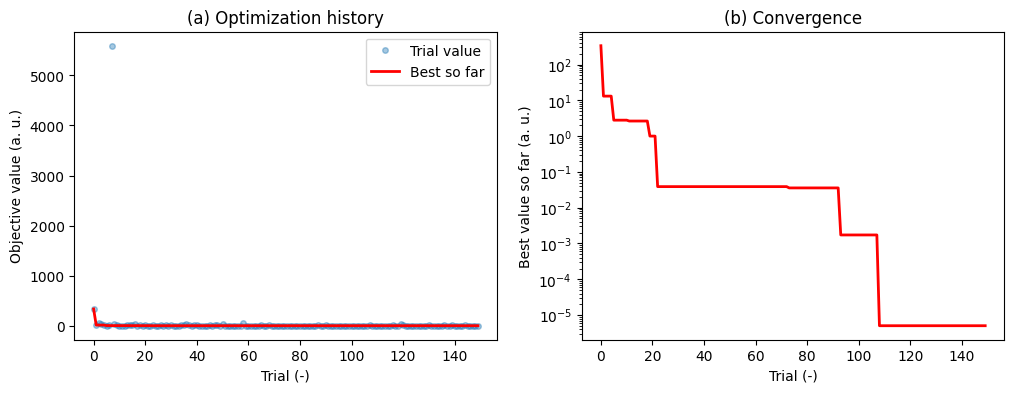

In [12]:
values = [t.value for t in study_combined.trials]
best_so_far = np.minimum.accumulate(values)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(values, 'o', alpha=0.4, markersize=4, label='Trial value')
axes[0].plot(best_so_far, 'r-', linewidth=2, label='Best so far')
axes[0].set_xlabel('Trial (-)')
axes[0].set_ylabel('Objective value (a. u.)')
axes[0].set_title('(a) Optimization history'); axes[0].legend()
axes[1].plot(best_so_far, 'r-', linewidth=2)
axes[1].set_xlabel('Trial (-)')
axes[1].set_ylabel('Best value so far (a. u.)')
axes[1].set_title('(b) Convergence')
axes[1].set_yscale('log')

## Fixing the Random Seed

By default, Optuna initialises its sampler with a random seed, so results differ between runs.
To make an optimization **reproducible**, pass a seeded sampler to `create_study`.

Optuna's default sampler is **TPESampler** (Tree-structured Parzen Estimator).
It accepts a `seed` argument that controls all internal random decisions:

```python
sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction='minimize', sampler=sampler)
```

With the same seed and the same objective, every run produces identical trials in the same order.

**Important**: reproducibility also requires `n_jobs=1` (the default).
Parallel execution (`n_jobs > 1`) introduces non-determinism that a fixed seed cannot eliminate.

In [13]:
def objective_seed(trial):
    x = trial.suggest_float('x', 0.0, 10.0)
    return (x - math.pi) ** 2

sampler = optuna.samplers.TPESampler(seed=42)

# Run the study twice with the same seed
for run in range(2):
    s = optuna.create_study(direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=42))
    s.optimize(objective_seed, n_trials=20)
    print(f"Run {run + 1}: best x = {s.best_params['x']:.6f}, "
          f"best value = {s.best_value:.2e}")

Run 1: best x = 3.468509, best value = 1.07e-01
Run 2: best x = 3.468509, best value = 1.07e-01


Both runs print identical results because the seed fully determines the sequence of sampled configurations.

**Exercise 4**: Run the two cells below.
The first study uses no seed; the second uses `seed=0`.
Which one gives the same `best_params` every time you restart the kernel and re-run?

```python
# Study A — no seed
study_a = optuna.create_study(direction='minimize')
study_a.optimize(objective_seed, n_trials=20)
print('A:', study_a.best_params)

# Study B — fixed seed
study_b = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=0)
)
study_b.optimize(objective_seed, n_trials=20)
print('B:', study_b.best_params)
```

**Solution**: Study B gives the same `best_params` on every restart because the seed fixes
the entire sequence of random decisions inside `TPESampler`.
Study A produces different results each time because no seed is set.

In [14]:
# Study A — no seed
study_a = optuna.create_study(direction='minimize')
study_a.optimize(objective_seed, n_trials=20)
print('A:', study_a.best_params)

# Study B — fixed seed
study_b = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=0)
)
study_b.optimize(objective_seed, n_trials=20)
print('B:', study_b.best_params)

A: {'x': 3.1590499736227873}
B: {'x': 3.1565984133102925}


## Revision Questions

- What is the difference between a **study** and a **trial** in Optuna?
- Which `suggest_*` method would you use for each of the following?
  - (a) Number of iterations $n \in \{10, 11, \ldots, 500\}$.
  - (b) A regularization strength $\lambda \in [10^{-5}, 10^{2}]$ spanning several orders of magnitude.
  - (c) The name of an optimizer: `'sgd'`, `'adam'`, or `'rmsprop'`.
  - (d) A step size chosen from the predefined list $\{0.001, 0.005, 0.01, 0.05, 0.1\}$.
- When should `log=True` be passed to `suggest_float`?
- What attributes of a completed `study` give you the best parameters and the best objective value?

## Revision Questions (Solutions (1/2))

- What is the difference between a **study** and a **trial** in Optuna?
  - A *study* is the full optimization run, collecting all evaluated configurations. A *trial* is a single evaluation of the objective function at one configuration.
- Which `suggest_*` method would you use for each of the following?
  - (a) `trial.suggest_int('n', 10, 500)` — integer range.
  - (b) `trial.suggest_float('lambda', 1e-5, 1e2, log=True)` — continuous, log-scale.
  - (c) `trial.suggest_categorical('optimizer', ['sgd', 'adam', 'rmsprop'])` — unordered string choices.
  - (d) `trial.suggest_categorical('step', [0.001, 0.005, 0.01, 0.05, 0.1])` — predefined list of values.

## Revision Questions (Solutions (2/2))

- When should `log=True` be passed to `suggest_float`?
  - When the parameter spans multiple orders of magnitude and relative differences matter more than absolute ones, so that each decade receives equal sampling probability.
- What attributes of a completed `study` give you the best parameters and the best objective value?
  - `study.best_params` (a dictionary) and `study.best_value` (a scalar).

## Questions?